Codigo .csv a .json

In [9]:
import pandas as pd

# 1. Definir los nombres exactos de las 13 columnas en orden
nombres_columnas = [
    'equipo', 
    'dorsal', 
    'nombre', 
    'posicion', 
    'fecha_nacimiento', 
    'edad', 
    'nacionalidad', 
    'altura', 
    'pie_dominante', 
    'fecha_llegada', 
    'club_procedente', 
    'fecha_contrato', 
    'valor_mercado'
]

# 2. Leer el CSV indicando el separador (;), la codificación (latin-1) y sin cabecera
df = pd.read_csv('futarg.csv', sep=';', encoding='latin-1', header=None, names=nombres_columnas)

# 3. Mostrar una vista previa rápida para verificar que quedó bien ordenado
print("--- Vista previa de los datos limpios ---")
print(df[['nombre', 'equipo', 'posicion', 'edad']].head())

# 4. Exportar a JSON correctamente estructurado
df.to_json('datos.json', orient='records', indent=4, force_ascii=False)

print("\n✅ ¡Éxito! El archivo 'futarg.csv' se convirtió y guardó como 'datos.json' perfectamente ordenado.")

--- Vista previa de los datos limpios ---
                  nombre equipo         posicion  edad
0       Santiago Beltrán  River          Portero    21
1     Ezequiel Centurión  River          Portero    29
2         Lautaro Rivero  River  Defensa central    22
3  Lucas Martínez Quarta  River  Defensa central    30
4         Tobías Ramírez  River  Defensa central    19

✅ ¡Éxito! El archivo 'futarg.csv' se convirtió y guardó como 'datos.json' perfectamente ordenado.


Graficos matlib

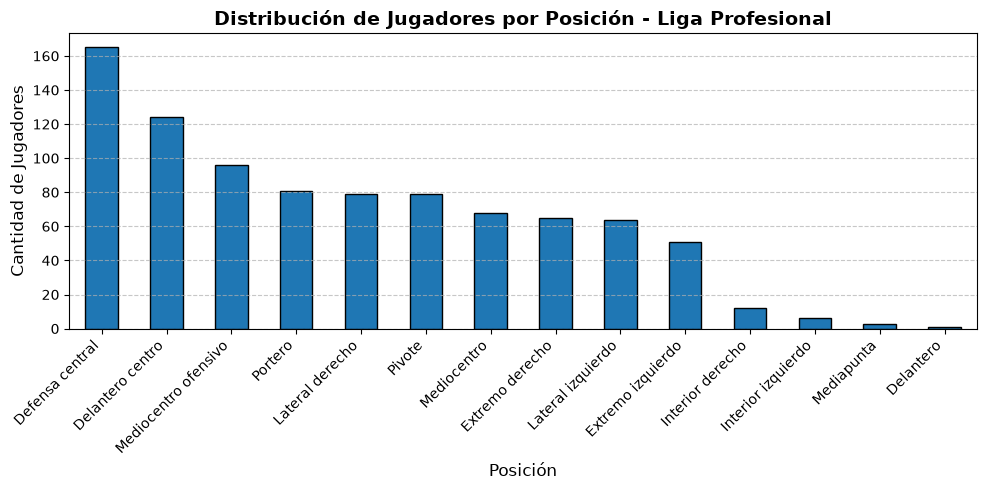

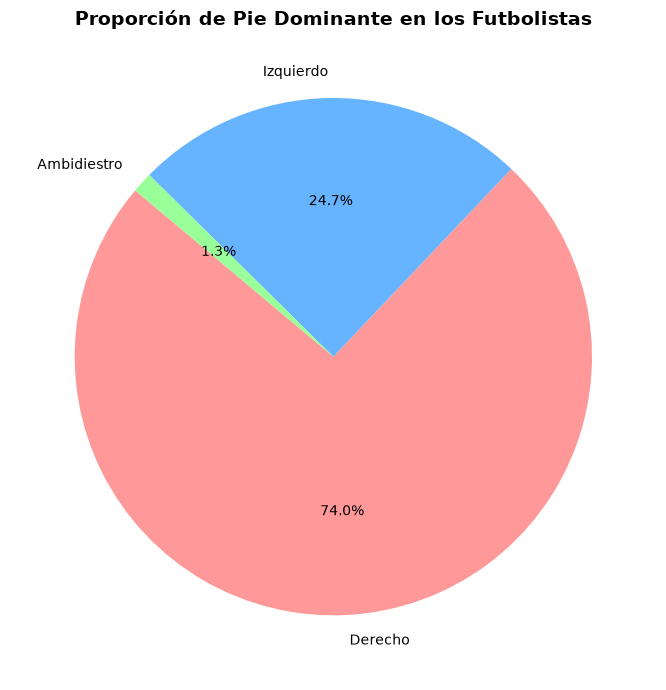

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos desde el JSON generado
df = pd.read_json('datos.json')

# --- GRÁFICO 1: Cantidad de jugadores por posición (Gráfico de Barras) ---
jugadores_por_posicion = df['posicion'].value_counts()

plt.figure(figsize=(10, 5))
jugadores_por_posicion.plot(kind='bar', color='#1f77b4', edgecolor='black')
plt.title('Distribución de Jugadores por Posición - Liga Profesional', fontsize=14, fontweight='bold')
plt.xlabel('Posición', fontsize=12)
plt.ylabel('Cantidad de Jugadores', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- GRÁFICO 2: Proporción de Pie Dominante (Gráfico de Torta / Circular) ---
# Limpiamos posibles espacios o valores nulos en la columna pie_dominante
pie_counts = df['pie_dominante'].value_counts()

plt.figure(figsize=(7, 7))
pie_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proporción de Pie Dominante en los Futbolistas', fontsize=14, fontweight='bold')
plt.ylabel('') # Oculta la etiqueta del eje y para mayor prolijidad
plt.tight_layout()
plt.show()

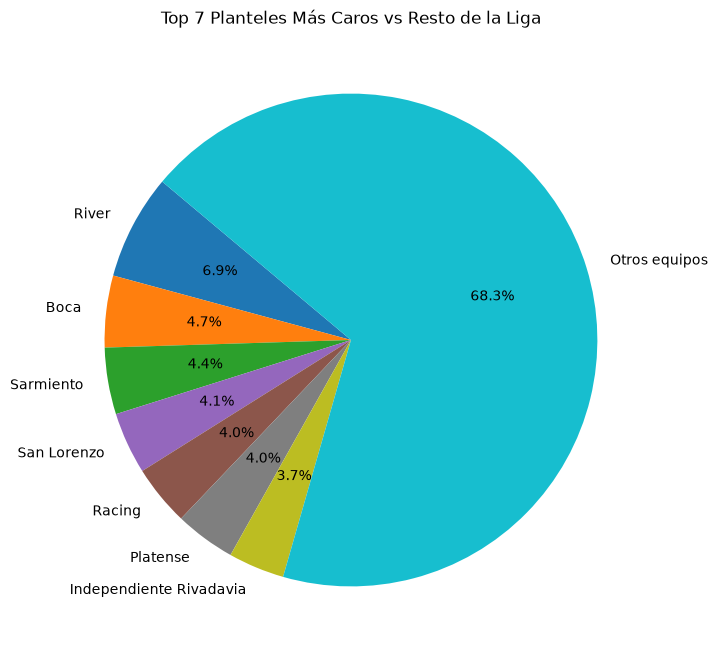

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargamos los datos
df = pd.read_json('datos.json')

# 2. Nos aseguramos de que 'valor_mercado' sea numérico (limpiando texto si lo hubiera)
df['valor_mercado'] = pd.to_numeric(
    df['valor_mercado'].astype(str).str.replace(r'[^0-9.]', '', regex=True), 
    errors='coerce'
).fillna(0)

# 3. Agrupamos por equipo y sumamos el valor de mercado
planteles_caros = df.groupby('equipo')['valor_mercado'].sum().sort_values(ascending=False)

# 4. Tomamos los 7 primeros y agrupamos el resto en "Otros"
top_7 = planteles_caros.head(7)
otros = pd.Series({'Otros equipos': planteles_caros.tail(len(planteles_caros) - 7).sum()})
datos_grafico = pd.concat([top_7, otros])

# 5. Creamos el gráfico de tortas
plt.figure(figsize=(8, 8))
datos_grafico.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    cmap='tab10'
)
plt.title('Top 7 Planteles Más Caros vs Resto de la Liga')
plt.ylabel('') # Oculta la etiqueta del eje Y
plt.show()